<a href="https://colab.research.google.com/github/alearecuest/anyoneai-exercises-sprint_1/blob/main/4_1_1_PRACTICE_Data_Visualization_with_Students_and_FIFA22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Visualization Practice

We present to you 2 challenging datasets without description and, it will be your job to do the proper analysis using Pandas, Statistics, and Data Visualization tools.

Guide your analysis using the Theory notebook already seen in the lectures.

If you find yourself stuck, try formulating questions and searching for an answer in your data.

Work in groups to brainstorm about the challenge.




In [1]:
import pandas as pd


## Admissions Prediction dataset

This dataset records the chance of being admitted to college of various prospective students in terms of their qualifications.

[Original source](https://github.com/Shankhanil/College-Admission-Predicion)

In [2]:
!gdown "1g8YpwUio5eCCeCCIaAEAd82GTwD1mvN4"

admissions_df = pd.read_csv("Admission_Predict.csv")
admissions_df

Downloading...
From: https://drive.google.com/uc?id=1g8YpwUio5eCCeCCIaAEAd82GTwD1mvN4
To: /content/Admission_Predict.csv
100% 12.9k/12.9k [00:00<00:00, 52.6MB/s]


,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65
...,...,...,...,...,...,...,...,...,...
395,396,324,110,3,3.5,3.5,9.04,1,0.82
396,397,325,107,3,3.0,3.5,9.11,1,0.84
397,398,330,116,4,5.0,4.5,9.45,1,0.91
398,399,312,103,3,3.5,4.0,8.78,0,0.67


ADMISSIONS DATASET ANALYSIS

Shape: (400, 8)
Missing values: 0

Statistical Summary:
          GRE   TOEFL  Uni_Rating     SOP     LOR    CGPA  Research  \
count  400.00  400.00      400.00  400.00  400.00  400.00    400.00   
mean   316.81  107.41        3.09    3.40    3.45    8.60      0.55   
std     11.47    6.07        1.14    1.01    0.90    0.60      0.50   
min    290.00   92.00        1.00    1.00    1.00    6.80      0.00   
25%    308.00  103.00        2.00    2.50    3.00    8.17      0.00   
50%    317.00  107.00        3.00    3.50    3.50    8.61      1.00   
75%    325.00  112.00        4.00    4.00    4.00    9.06      1.00   
max    340.00  120.00        5.00    5.00    5.00    9.92      1.00   

       Admit_Chance  
count        400.00  
mean           0.72  
std            0.14  
min            0.34  
25%            0.64  
50%            0.73  
75%            0.83  
max            0.97  


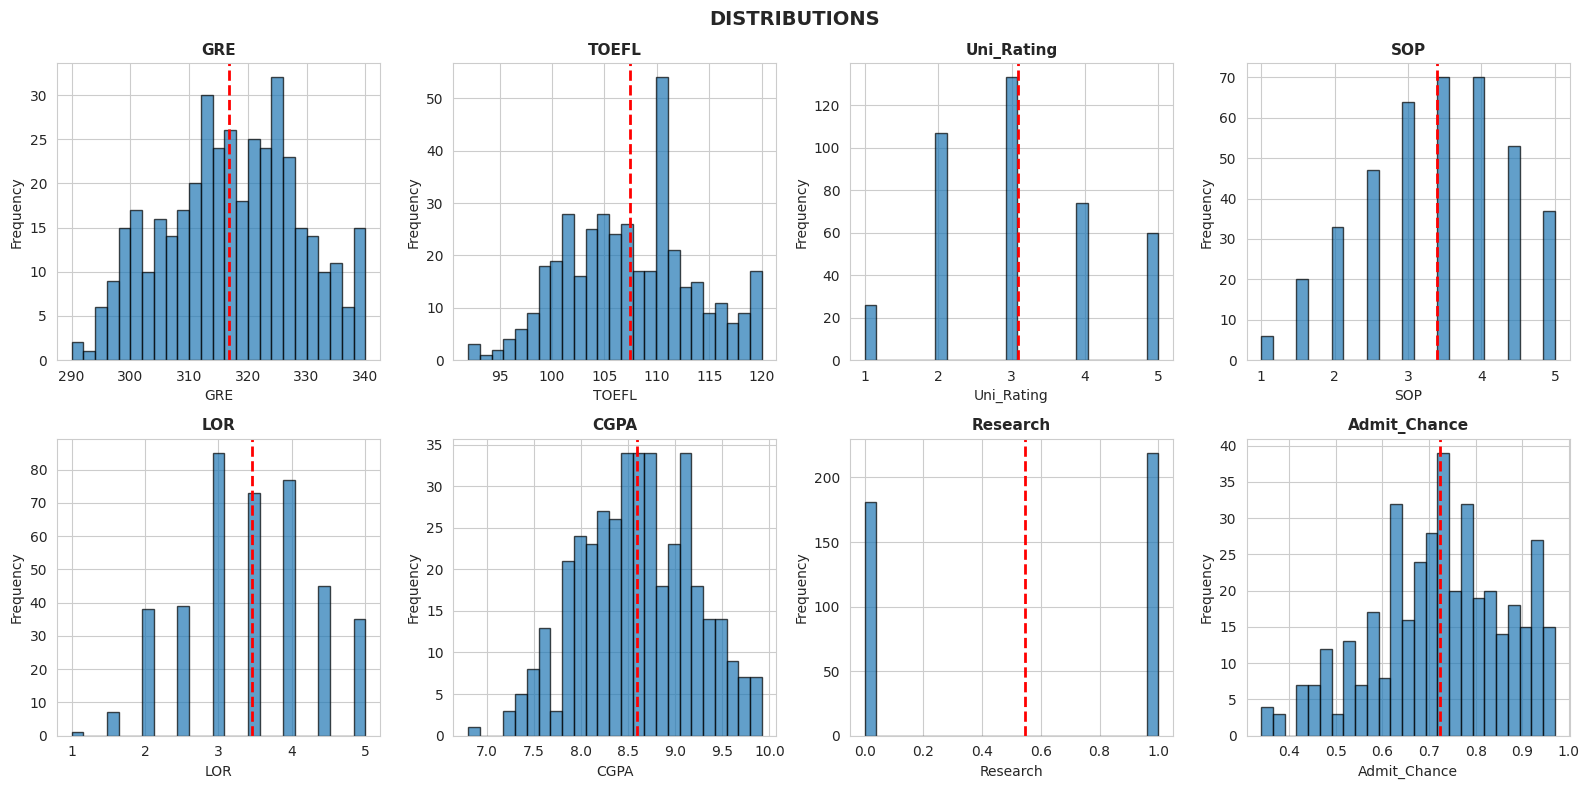

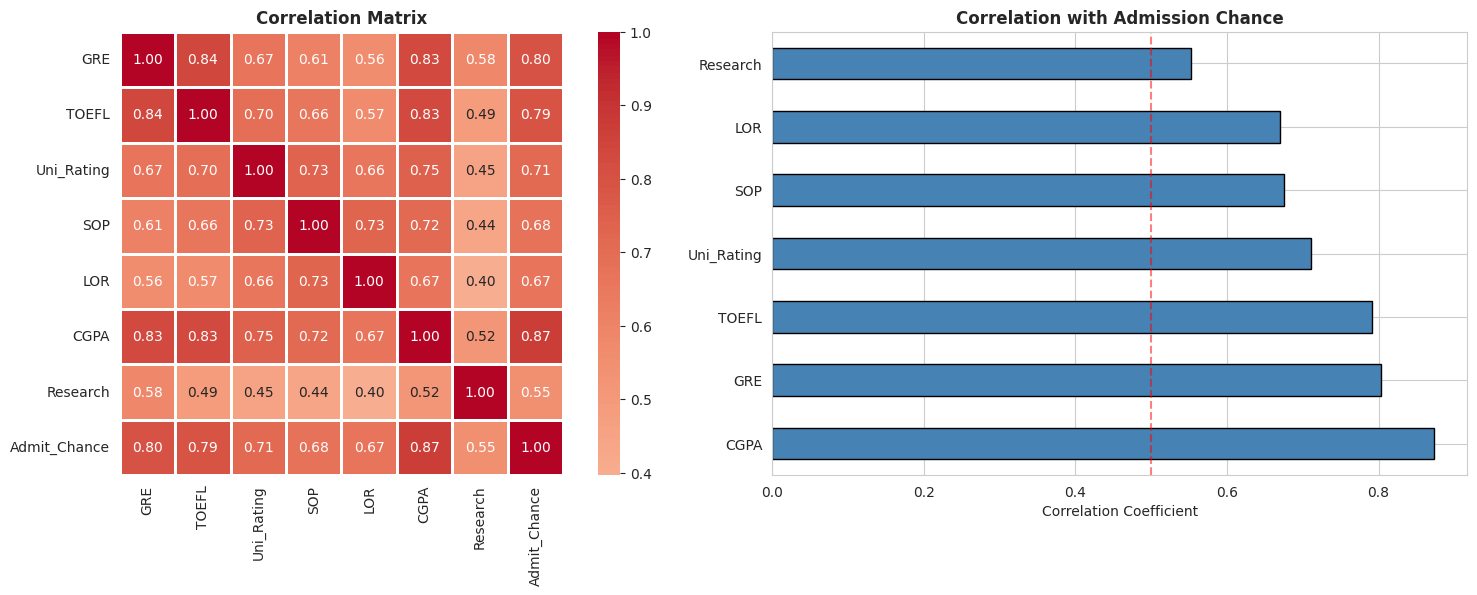


Correlations with Admission Chance:
CGPA          0.873289
GRE           0.802610
TOEFL         0.791594
Uni_Rating    0.711250
SOP           0.675732
LOR           0.669889
Research      0.553202
Name: Admit_Chance, dtype: float64


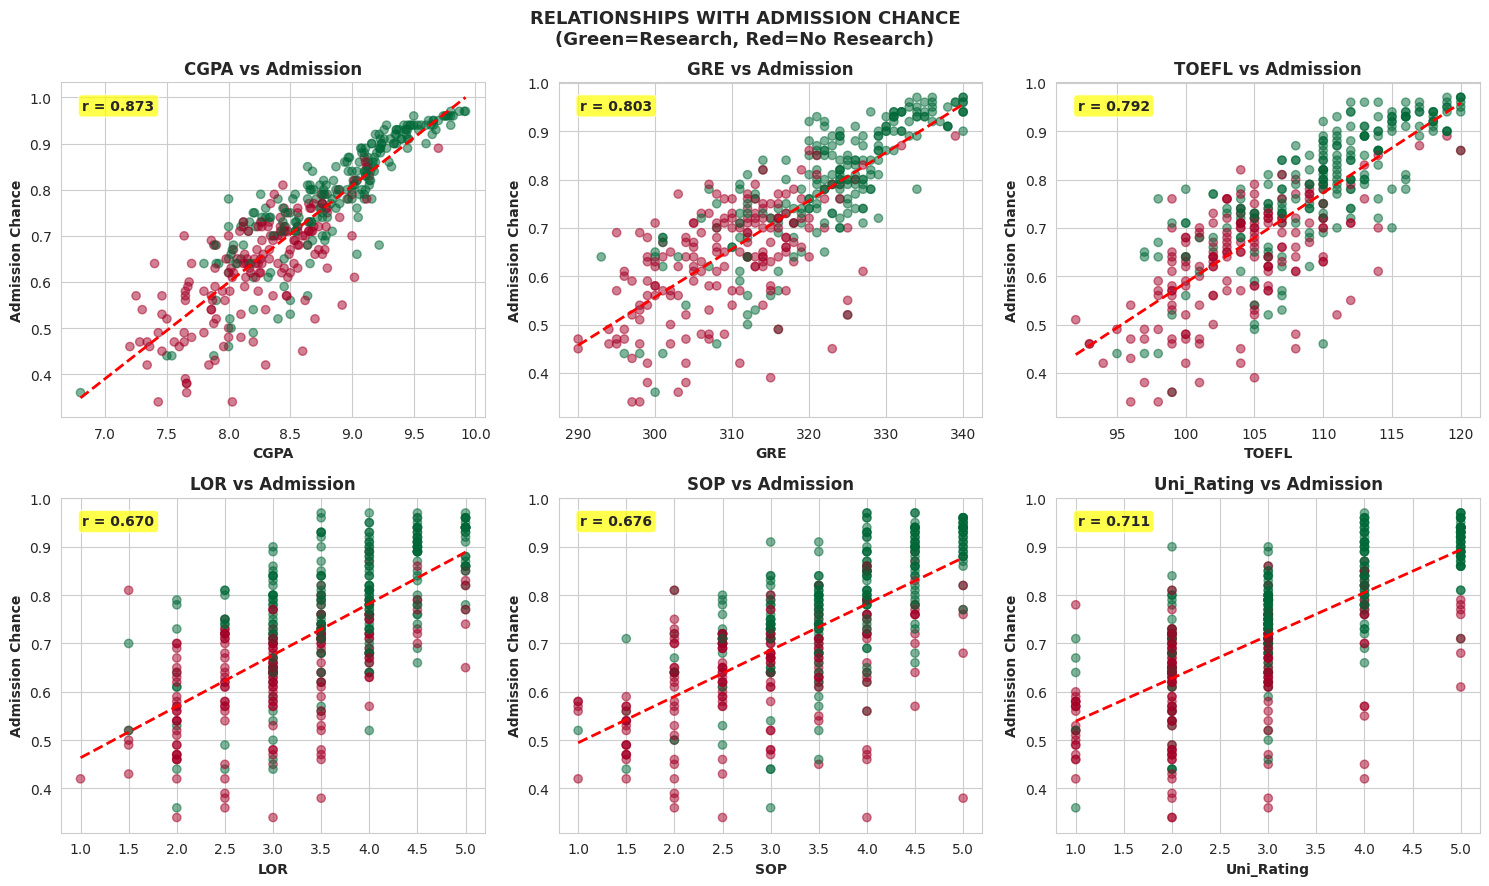

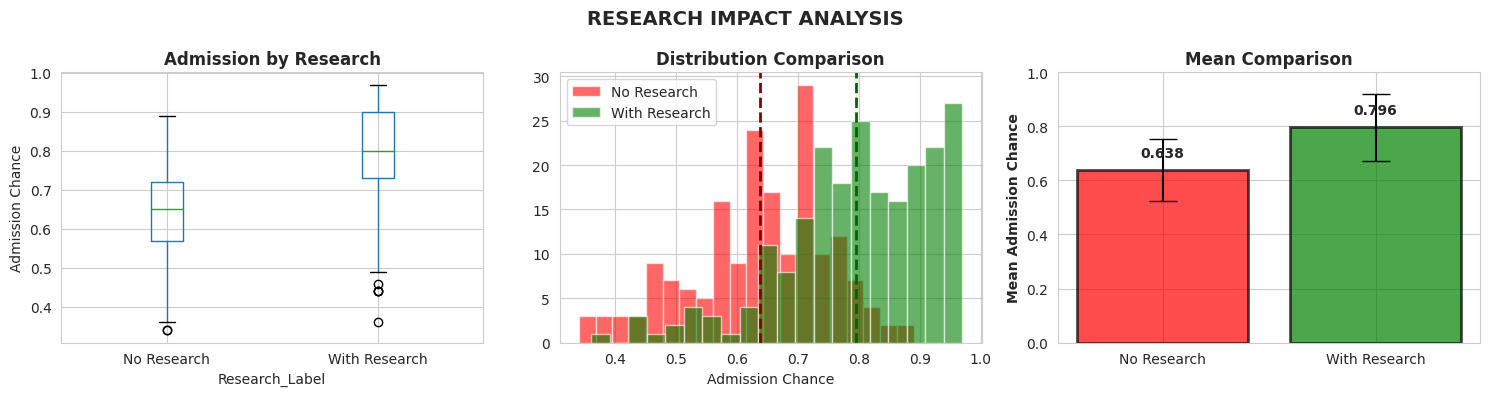


RESEARCH IMPACT
Mean WITH research:    0.7960
Mean WITHOUT research: 0.6377
Difference:            0.1583
T-statistic:           13.2482
P-value:               1.92e-33
Significant:           YES


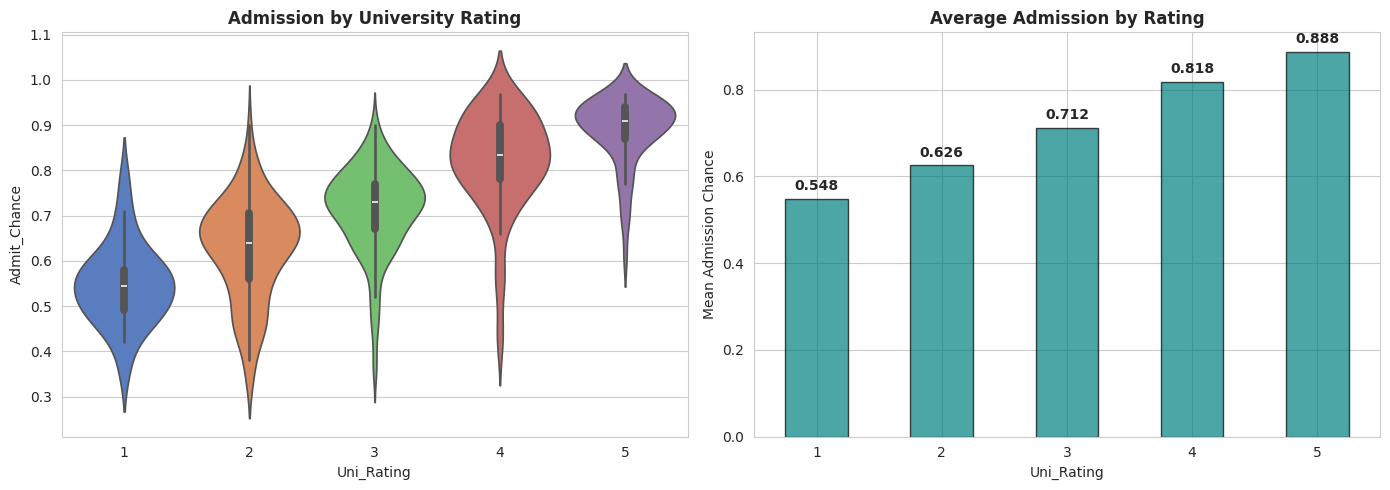


KEY FINDINGS
1. Strongest predictor: CGPA (r=0.873)
2. Research increases admission by 15.8 percentage points
3. GRE correlation: 0.803
4. TOEFL correlation: 0.792


In [4]:
# ============================================================================
# ADMISSIONS PREDICTION DATASET - COMPLETE ANALYSIS
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')

# Data already loaded as admissions_df
# Clean data
df = admissions_df.drop('Serial No.', axis=1).copy()
df.columns = ['GRE', 'TOEFL', 'Uni_Rating', 'SOP', 'LOR', 'CGPA', 'Research', 'Admit_Chance']

print("="*70)
print("ADMISSIONS DATASET ANALYSIS")
print("="*70)
print(f"\nShape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
print("\nStatistical Summary:")
print(df.describe().round(2))

# ============================================================================
# 1. DISTRIBUTIONS
# ============================================================================
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for idx, col in enumerate(df.columns):
    axes[idx].hist(df[col], bins=25, edgecolor='black', alpha=0.7)
    axes[idx].axvline(df[col].mean(), color='red', linestyle='--', linewidth=2)
    axes[idx].set_title(f'{col}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')

plt.suptitle('DISTRIBUTIONS', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================================
# 2. CORRELATION ANALYSIS
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, ax=axes[0], linewidths=1)
axes[0].set_title('Correlation Matrix', fontsize=12, fontweight='bold')

# Correlations with Admit_Chance
admit_corr = corr['Admit_Chance'].sort_values(ascending=False).drop('Admit_Chance')
admit_corr.plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Correlation with Admission Chance', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Correlation Coefficient')
axes[1].axvline(x=0.5, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("\nCorrelations with Admission Chance:")
print(admit_corr)

# ============================================================================
# 3. KEY RELATIONSHIPS
# ============================================================================
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

predictors = ['CGPA', 'GRE', 'TOEFL', 'LOR', 'SOP', 'Uni_Rating']

for idx, col in enumerate(predictors):
    axes[idx].scatter(df[col], df['Admit_Chance'], alpha=0.5,
                     c=df['Research'], cmap='RdYlGn')

    # Trend line
    z = np.polyfit(df[col], df['Admit_Chance'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    axes[idx].plot(x_line, p(x_line), "r--", linewidth=2)

    corr_val = df[col].corr(df['Admit_Chance'])
    axes[idx].text(0.05, 0.95, f'r = {corr_val:.3f}', transform=axes[idx].transAxes,
                   bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7),
                   verticalalignment='top', fontsize=10, fontweight='bold')

    axes[idx].set_xlabel(col, fontweight='bold')
    axes[idx].set_ylabel('Admission Chance', fontweight='bold')
    axes[idx].set_title(f'{col} vs Admission', fontweight='bold')

plt.suptitle('RELATIONSHIPS WITH ADMISSION CHANCE\n(Green=Research, Red=No Research)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================================
# 4. RESEARCH IMPACT
# ============================================================================
research_yes = df[df['Research'] == 1]['Admit_Chance']
research_no = df[df['Research'] == 0]['Admit_Chance']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Boxplot
df['Research_Label'] = df['Research'].map({0: 'No Research', 1: 'With Research'})
df.boxplot(column='Admit_Chance', by='Research_Label', ax=axes[0])
axes[0].set_title('Admission by Research', fontweight='bold')
axes[0].set_ylabel('Admission Chance')

# Histograms
axes[1].hist(research_no, bins=20, alpha=0.6, label='No Research', color='red')
axes[1].hist(research_yes, bins=20, alpha=0.6, label='With Research', color='green')
axes[1].axvline(research_no.mean(), color='darkred', linestyle='--', linewidth=2)
axes[1].axvline(research_yes.mean(), color='darkgreen', linestyle='--', linewidth=2)
axes[1].set_xlabel('Admission Chance')
axes[1].set_title('Distribution Comparison', fontweight='bold')
axes[1].legend()

# Bar chart
stats_data = df.groupby('Research_Label')['Admit_Chance'].agg(['mean', 'std', 'count'])
axes[2].bar(range(2), stats_data['mean'], yerr=stats_data['std'],
           color=['red', 'green'], alpha=0.7, capsize=10, edgecolor='black', linewidth=2)
axes[2].set_xticks(range(2))
axes[2].set_xticklabels(stats_data.index)
axes[2].set_ylabel('Mean Admission Chance', fontweight='bold')
axes[2].set_title('Mean Comparison', fontweight='bold')
axes[2].set_ylim(0, 1)

for i, v in enumerate(stats_data['mean']):
    axes[2].text(i, v + 0.05, f'{v:.3f}', ha='center', fontweight='bold')

plt.suptitle('RESEARCH IMPACT ANALYSIS', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Statistical test
t_stat, p_value = stats.ttest_ind(research_yes, research_no)
print("\n" + "="*70)
print("RESEARCH IMPACT")
print("="*70)
print(f"Mean WITH research:    {research_yes.mean():.4f}")
print(f"Mean WITHOUT research: {research_no.mean():.4f}")
print(f"Difference:            {research_yes.mean() - research_no.mean():.4f}")
print(f"T-statistic:           {t_stat:.4f}")
print(f"P-value:               {p_value:.2e}")
print(f"Significant:           {'YES' if p_value < 0.05 else 'NO'}")

# ============================================================================
# 5. UNIVERSITY RATING IMPACT
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.violinplot(data=df, x='Uni_Rating', y='Admit_Chance', ax=axes[0], palette='muted')
axes[0].set_title('Admission by University Rating', fontsize=12, fontweight='bold')

uni_stats = df.groupby('Uni_Rating')['Admit_Chance'].mean()
uni_stats.plot(kind='bar', ax=axes[1], color='teal', edgecolor='black', alpha=0.7)
axes[1].set_title('Average Admission by Rating', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Mean Admission Chance')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

for i, v in enumerate(uni_stats.values):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("KEY FINDINGS")
print("="*70)
print(f"1. Strongest predictor: CGPA (r={corr['Admit_Chance']['CGPA']:.3f})")
print(f"2. Research increases admission by {(research_yes.mean()-research_no.mean())*100:.1f} percentage points")
print(f"3. GRE correlation: {corr['Admit_Chance']['GRE']:.3f}")
print(f"4. TOEFL correlation: {corr['Admit_Chance']['TOEFL']:.3f}")
print("="*70)

## FIFA22 Dataset

This complex dataset (60 columns, ~20k samples) has information about soccer players from the game. Therefore, many columns are only relevant to the game (which?), but others contain real information that can be used to understand the status of soccer worldwide.

[Original source](https://www.kaggle.com/datasets/stefanoleone992/fifa-22-complete-player-dataset?resource=download&select=players_22.csv)



In [5]:
!gdown "1ebH7vO9KLEb_LPbK2lCJID6oFk3CKeB5"

df = pd.read_csv("players_22.csv")
df

Downloading...
From: https://drive.google.com/uc?id=1ebH7vO9KLEb_LPbK2lCJID6oFk3CKeB5
To: /content/players_22.csv
100% 13.6M/13.6M [00:00<00:00, 62.2MB/s]


,sofifa_id,player_url,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,age,...,lcb,cb,rcb,rb,gk,player_face_url,club_logo_url,club_flag_url,nation_logo_url,nation_flag_url
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,"RW, ST, CF",93,93,78000000.0,320000.0,34,...,50+3,50+3,50+3,61+3,19+3,https://cdn.sofifa.net/players/158/023/22_120.png,https://cdn.sofifa.net/teams/73/60.png,https://cdn.sofifa.net/flags/fr.png,https://cdn.sofifa.net/teams/1369/60.png,https://cdn.sofifa.net/flags/ar.png
1,188545,https://sofifa.com/player/188545/robert-lewand...,R. Lewandowski,Robert Lewandowski,ST,92,92,119500000.0,270000.0,32,...,60+3,60+3,60+3,61+3,19+3,https://cdn.sofifa.net/players/188/545/22_120.png,https://cdn.sofifa.net/teams/21/60.png,https://cdn.sofifa.net/flags/de.png,https://cdn.sofifa.net/teams/1353/60.png,https://cdn.sofifa.net/flags/pl.png
2,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,"ST, LW",91,91,45000000.0,270000.0,36,...,53+3,53+3,53+3,60+3,20+3,https://cdn.sofifa.net/players/020/801/22_120.png,https://cdn.sofifa.net/teams/11/60.png,https://cdn.sofifa.net/flags/gb-eng.png,https://cdn.sofifa.net/teams/1354/60.png,https://cdn.sofifa.net/flags/pt.png
3,190871,https://sofifa.com/player/190871/neymar-da-sil...,Neymar Jr,Neymar da Silva Santos Júnior,"LW, CAM",91,91,129000000.0,270000.0,29,...,50+3,50+3,50+3,62+3,20+3,https://cdn.sofifa.net/players/190/871/22_120.png,https://cdn.sofifa.net/teams/73/60.png,https://cdn.sofifa.net/flags/fr.png,NaN,https://cdn.sofifa.net/flags/br.png
4,192985,https://sofifa.com/player/192985/kevin-de-bruy...,K. De Bruyne,Kevin De Bruyne,"CM, CAM",91,91,125500000.0,350000.0,30,...,69+3,69+3,69+3,75+3,21+3,https://cdn.sofifa.net/players/192/985/22_120.png,https://cdn.sofifa.net/teams/10/60.png,https://cdn.sofifa.net/flags/gb-eng.png,https://cdn.sofifa.net/teams/1325/60.png,https://cdn.sofifa.net/flags/be.png
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19234,261962,https://sofifa.com/player/261962/defu-song/220002,Song Defu,宋德福,CDM,47,52,70000.0,1000.0,22,...,46+2,46+2,46+2,48+2,15+2,https://cdn.sofifa.net/players/261/962/22_120.png,https://cdn.sofifa.net/teams/112541/60.png,https://cdn.sofifa.net/flags/cn.png,NaN,https://cdn.sofifa.net/flags/cn.png
19235,262040,https://sofifa.com/player/262040/caoimhin-port...,C. Porter,Caoimhin Porter,CM,47,59,110000.0,500.0,19,...,44+2,44+2,44+2,48+2,14+2,https://cdn.sofifa.net/players/262/040/22_120.png,https://cdn.sofifa.net/teams/445/60.png,https://cdn.sofifa.net/flags/ie.png,NaN,https://cdn.sofifa.net/flags/ie.png
19236,262760,https://sofifa.com/player/262760/nathan-logue/...,N. Logue,Nathan Logue-Cunningham,CM,47,55,100000.0,500.0,21,...,45+2,45+2,45+2,47+2,12+2,https://cdn.sofifa.net/players/262/760/22_120.png,https://cdn.sofifa.net/teams/111131/60.png,https://cdn.sofifa.net/flags/ie.png,NaN,https://cdn.sofifa.net/flags/ie.png
19237,262820,https://sofifa.com/player/262820/luke-rudden/2...,L. Rudden,Luke Rudden,ST,47,60,110000.0,500.0,19,...,26+2,26+2,26+2,32+2,15+2,https://cdn.sofifa.net/players/262/820/22_120.png,https://cdn.sofifa.net/teams/111131/60.png,https://cdn.sofifa.net/flags/ie.png,NaN,https://cdn.sofifa.net/flags/ie.png


FIFA 22 DATASET ANALYSIS

Shape: (19239, 19)
Players: 19,239
Missing values: 13,049

Basic Statistics:
            age   overall  potential     value_eur
count  19239.00  19239.00   19239.00  1.916500e+04
mean      25.21     65.77      71.08  2.850452e+06
std        4.75      6.88       6.09  7.613700e+06
min       16.00     47.00      49.00  9.000000e+03
25%       21.00     61.00      67.00  4.750000e+05
50%       25.00     66.00      71.00  9.750000e+05
75%       29.00     70.00      75.00  2.000000e+06
max       54.00     93.00      95.00  1.940000e+08


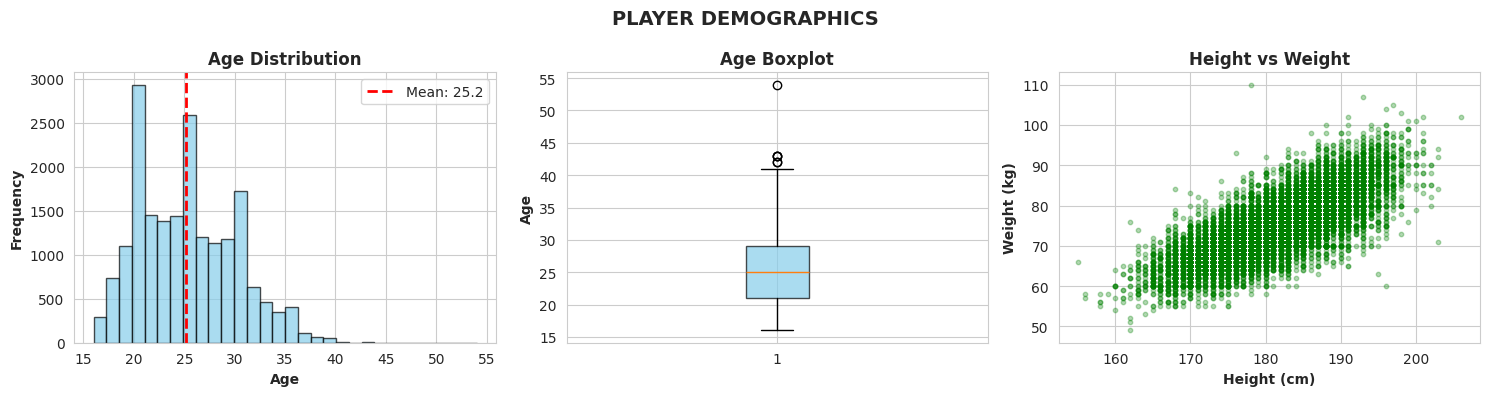

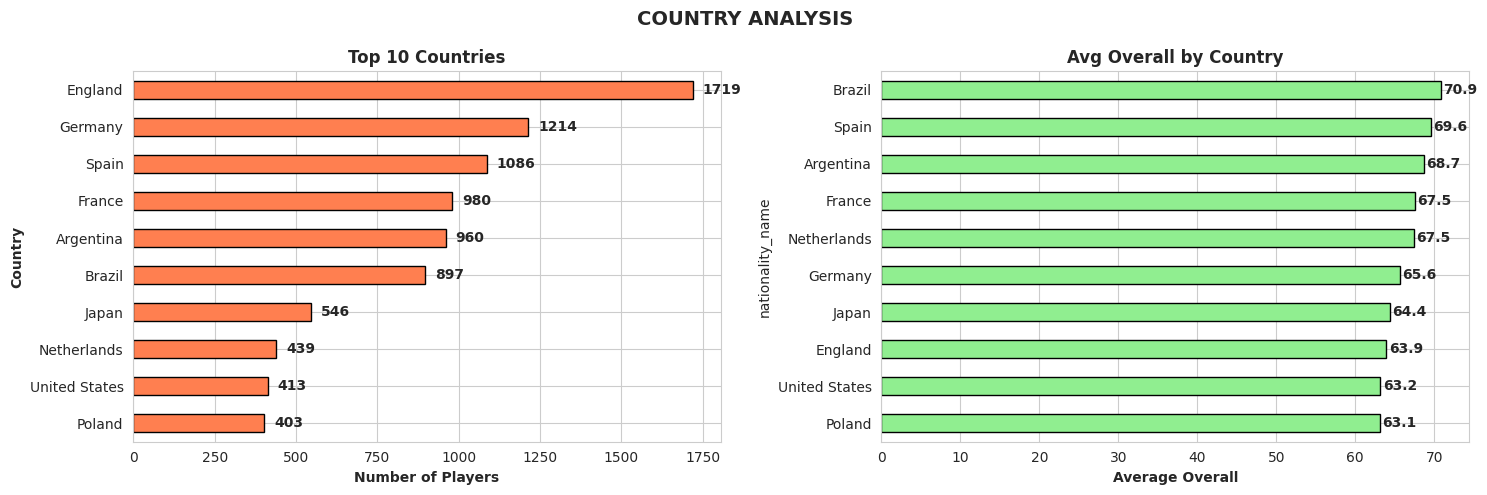


Top 10 Countries:
nationality_name
England          1719
Germany          1214
Spain            1086
France            980
Argentina         960
Brazil            897
Japan             546
Netherlands       439
United States     413
Poland            403
Name: count, dtype: int64


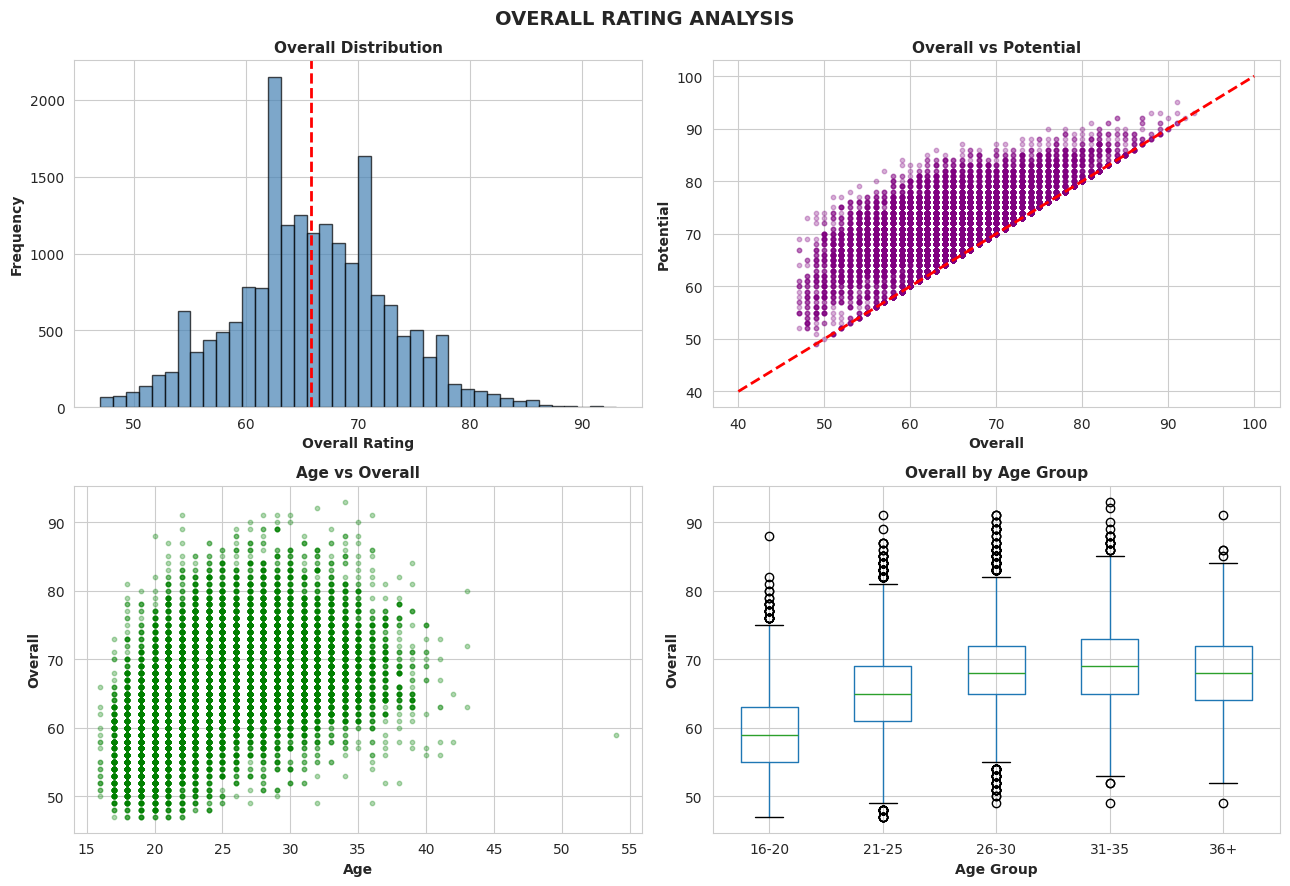


Average Overall by Age Group:
age_group
16-20    59.32
21-25    65.38
26-30    68.54
31-35    69.28
36+      68.35
Name: overall, dtype: float64


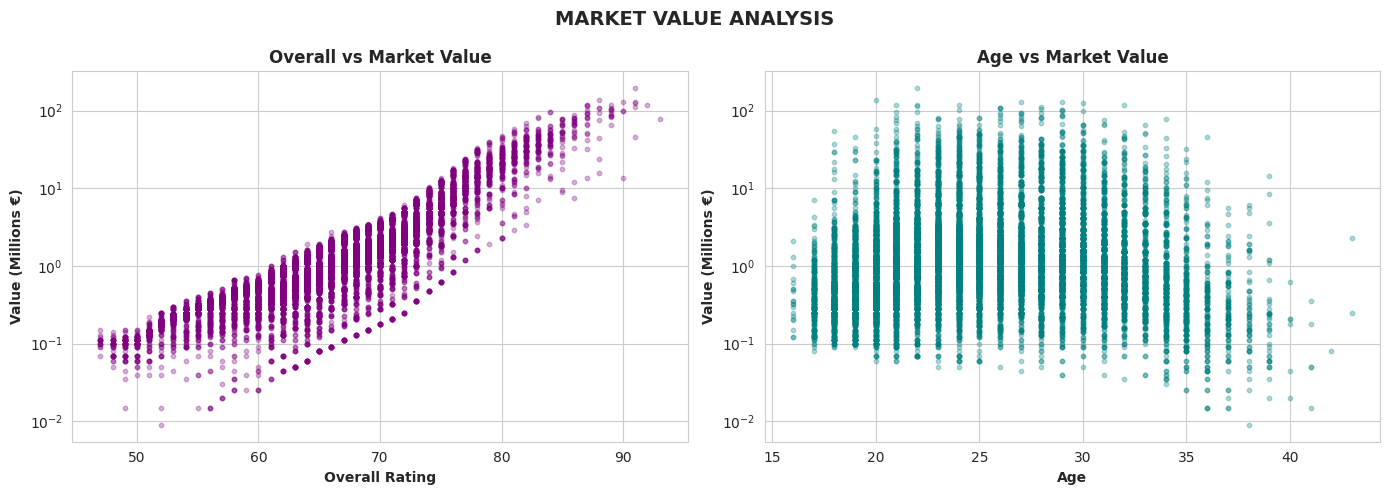


Top 10 Most Valuable Players:
               Name  Age  Overall     Country  Value(M€)
          K. Mbappé   22       91      France      194.0
         E. Haaland   20       88      Norway      137.5
            H. Kane   27       90     England      129.5
          Neymar Jr   29       91      Brazil      129.0
       K. De Bruyne   30       91     Belgium      125.5
     R. Lewandowski   32       92      Poland      119.5
      G. Donnarumma   22       89       Italy      119.5
         F. de Jong   24       87 Netherlands      119.5
          J. Sancho   21       87     England      116.5
T. Alexander-Arnold   22       87     England      114.0


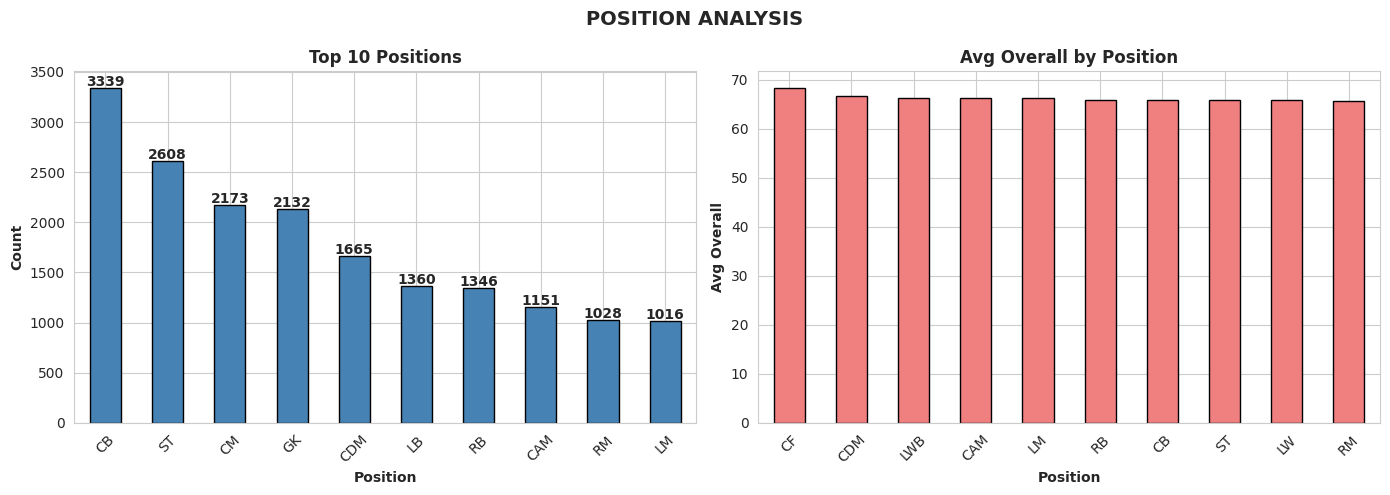

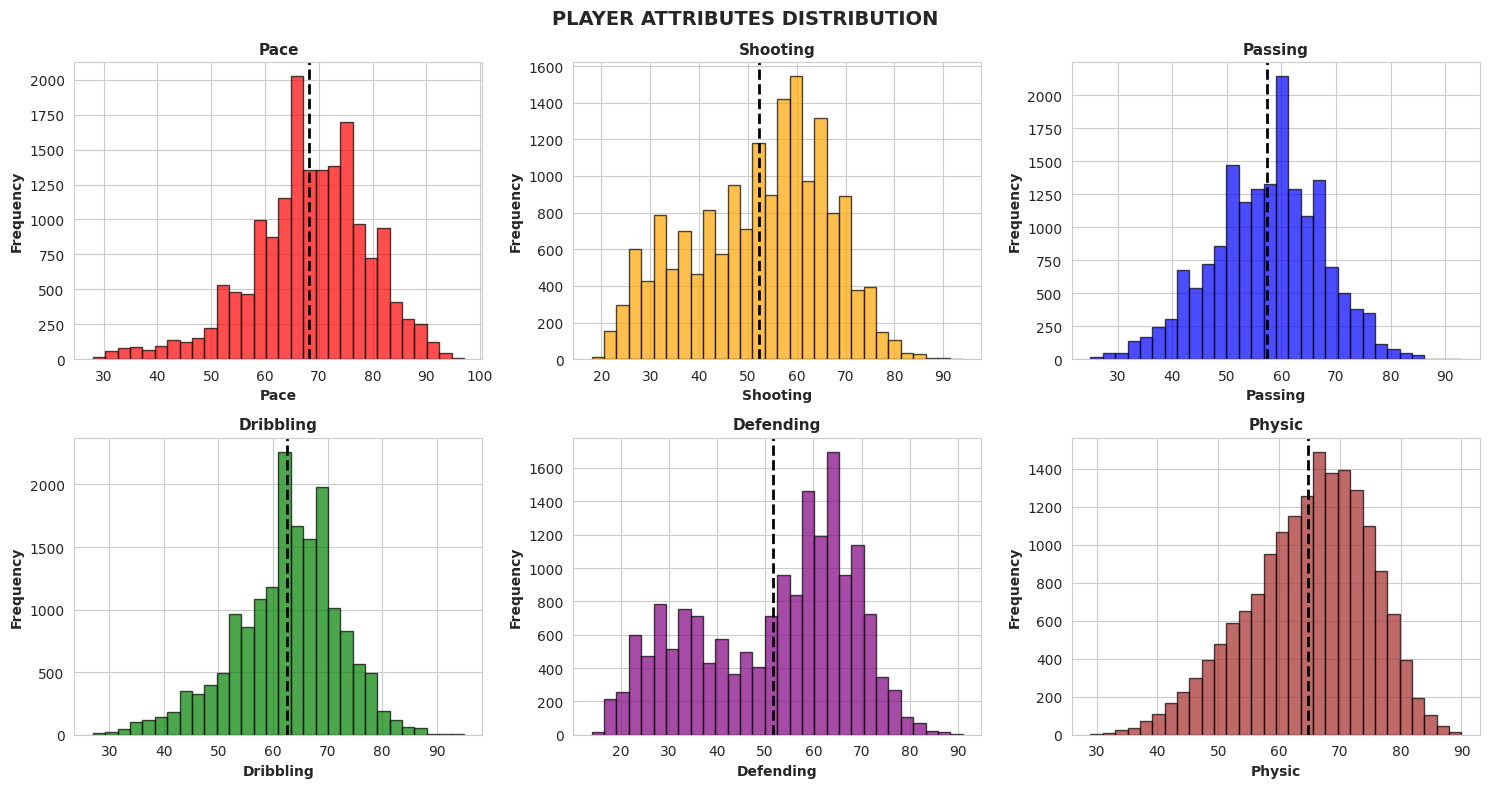

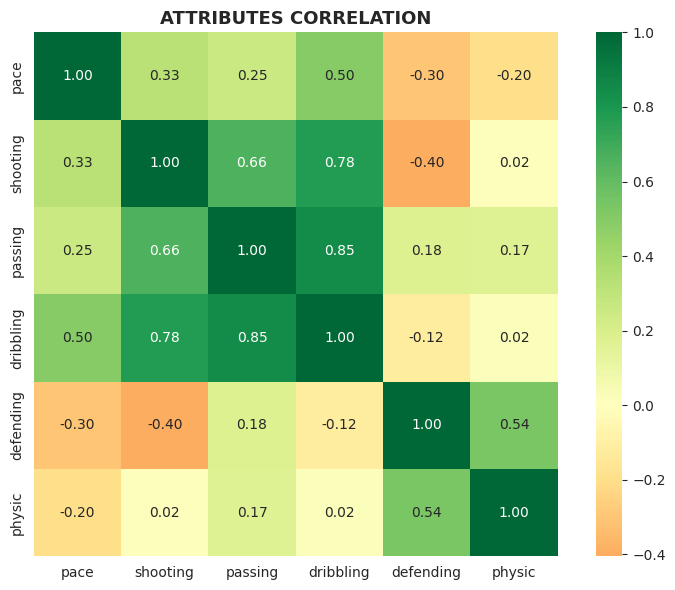

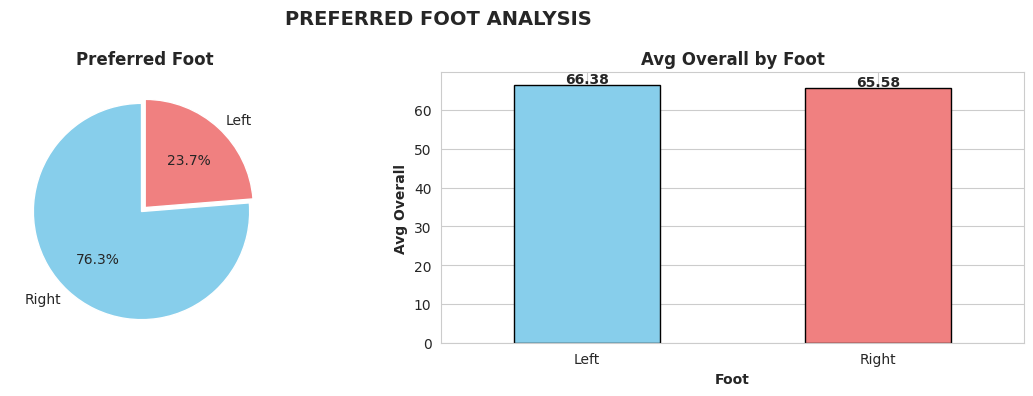


Left-footed: 23.7%
Right-footed: 76.3%

ELITE PLAYERS (Overall >= 85)
Total: 97 (0.50%)


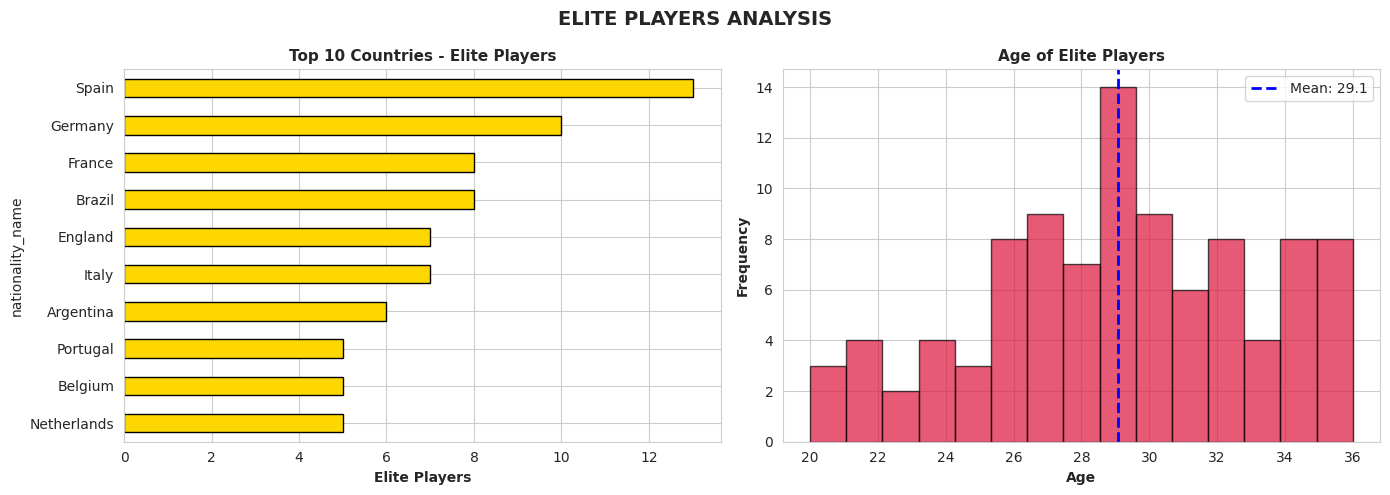


Top 10 Elite Players:
             Name  Age  Overall   Country
         L. Messi   34       93 Argentina
   R. Lewandowski   32       92    Poland
Cristiano Ronaldo   36       91  Portugal
        Neymar Jr   29       91    Brazil
     K. De Bruyne   30       91   Belgium
         J. Oblak   28       91  Slovenia
        K. Mbappé   22       91    France
         M. Neuer   35       90   Germany
    M. ter Stegen   29       90   Germany
          H. Kane   27       90   England

KEY FINDINGS - FIFA 22
1. Total players: 19,239
2. Mean age: 25.2 years
3. Peak age group: 31-35
4. Elite players: 97 (0.50%)
5. Most common position: CB (3339 players)
6. Left-footed players: 23.7%
7. Top country: England (1719 players)


In [6]:
# ============================================================================
# FIFA 22 DATASET - COMPLETE ANALYSIS
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')

# Data already loaded as df
# Select key columns
key_cols = ['short_name', 'age', 'height_cm', 'weight_kg', 'overall', 'potential',
            'value_eur', 'wage_eur', 'nationality_name', 'club_name', 'league_name',
            'player_positions', 'preferred_foot', 'pace', 'shooting',
            'passing', 'dribbling', 'defending', 'physic']

fifa = df[key_cols].copy()

print("="*70)
print("FIFA 22 DATASET ANALYSIS")
print("="*70)
print(f"\nShape: {fifa.shape}")
print(f"Players: {len(fifa):,}")
print(f"Missing values: {fifa.isnull().sum().sum():,}")
print("\nBasic Statistics:")
print(fifa[['age', 'overall', 'potential', 'value_eur']].describe().round(2))

# ============================================================================
# 1. PLAYER DEMOGRAPHICS
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Age distribution
axes[0].hist(fifa['age'].dropna(), bins=30, edgecolor='black', alpha=0.7, color='skyblue')
axes[0].axvline(fifa['age'].mean(), color='red', linestyle='--', linewidth=2,
                label=f'Mean: {fifa["age"].mean():.1f}')
axes[0].set_xlabel('Age', fontweight='bold')
axes[0].set_ylabel('Frequency', fontweight='bold')
axes[0].set_title('Age Distribution', fontsize=12, fontweight='bold')
axes[0].legend()

# Age boxplot
axes[1].boxplot(fifa['age'].dropna(), patch_artist=True,
                boxprops=dict(facecolor='skyblue', alpha=0.7))
axes[1].set_ylabel('Age', fontweight='bold')
axes[1].set_title('Age Boxplot', fontsize=12, fontweight='bold')

# Height vs Weight
axes[2].scatter(fifa['height_cm'], fifa['weight_kg'], alpha=0.3, s=10, color='green')
axes[2].set_xlabel('Height (cm)', fontweight='bold')
axes[2].set_ylabel('Weight (kg)', fontweight='bold')
axes[2].set_title('Height vs Weight', fontsize=12, fontweight='bold')

plt.suptitle('PLAYER DEMOGRAPHICS', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================================
# 2. TOP COUNTRIES
# ============================================================================
top_countries = fifa['nationality_name'].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

top_countries.plot(kind='barh', ax=axes[0], color='coral', edgecolor='black')
axes[0].set_xlabel('Number of Players', fontweight='bold')
axes[0].set_ylabel('Country', fontweight='bold')
axes[0].set_title('Top 10 Countries', fontsize=12, fontweight='bold')
axes[0].invert_yaxis()

for i, v in enumerate(top_countries.values):
    axes[0].text(v + 30, i, str(v), va='center', fontweight='bold')

# Average overall by country
avg_overall = fifa[fifa['nationality_name'].isin(top_countries.index)].groupby('nationality_name')['overall'].mean().sort_values(ascending=False)
avg_overall.plot(kind='barh', ax=axes[1], color='lightgreen', edgecolor='black')
axes[1].set_xlabel('Average Overall', fontweight='bold')
axes[1].set_title('Avg Overall by Country', fontsize=12, fontweight='bold')
axes[1].invert_yaxis()

for i, v in enumerate(avg_overall.values):
    axes[1].text(v + 0.3, i, f'{v:.1f}', va='center', fontweight='bold')

plt.suptitle('COUNTRY ANALYSIS', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nTop 10 Countries:")
print(top_countries)

# ============================================================================
# 3. OVERALL RATING ANALYSIS
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Distribution
axes[0,0].hist(fifa['overall'].dropna(), bins=40, edgecolor='black', alpha=0.7, color='steelblue')
axes[0,0].axvline(fifa['overall'].mean(), color='red', linestyle='--', linewidth=2)
axes[0,0].set_xlabel('Overall Rating', fontweight='bold')
axes[0,0].set_ylabel('Frequency', fontweight='bold')
axes[0,0].set_title('Overall Distribution', fontsize=11, fontweight='bold')

# Overall vs Potential
axes[0,1].scatter(fifa['overall'], fifa['potential'], alpha=0.3, s=10, color='purple')
axes[0,1].plot([40, 100], [40, 100], 'r--', linewidth=2)
axes[0,1].set_xlabel('Overall', fontweight='bold')
axes[0,1].set_ylabel('Potential', fontweight='bold')
axes[0,1].set_title('Overall vs Potential', fontsize=11, fontweight='bold')

# Age vs Overall
axes[1,0].scatter(fifa['age'], fifa['overall'], alpha=0.3, s=10, color='green')
axes[1,0].set_xlabel('Age', fontweight='bold')
axes[1,0].set_ylabel('Overall', fontweight='bold')
axes[1,0].set_title('Age vs Overall', fontsize=11, fontweight='bold')

# Overall by age group
fifa['age_group'] = pd.cut(fifa['age'], bins=[15, 20, 25, 30, 35, 45],
                            labels=['16-20', '21-25', '26-30', '31-35', '36+'])
fifa.boxplot(column='overall', by='age_group', ax=axes[1,1])
axes[1,1].set_xlabel('Age Group', fontweight='bold')
axes[1,1].set_ylabel('Overall', fontweight='bold')
axes[1,1].set_title('Overall by Age Group', fontsize=11, fontweight='bold')

plt.suptitle('OVERALL RATING ANALYSIS', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nAverage Overall by Age Group:")
print(fifa.groupby('age_group')['overall'].mean().round(2))

# ============================================================================
# 4. MARKET VALUE
# ============================================================================
fifa_value = fifa[fifa['value_eur'] > 0].copy()
fifa_value['value_millions'] = fifa_value['value_eur'] / 1_000_000

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall vs Value
axes[0].scatter(fifa_value['overall'], fifa_value['value_millions'], alpha=0.3, s=10, color='purple')
axes[0].set_xlabel('Overall Rating', fontweight='bold')
axes[0].set_ylabel('Value (Millions €)', fontweight='bold')
axes[0].set_title('Overall vs Market Value', fontsize=12, fontweight='bold')
axes[0].set_yscale('log')

# Age vs Value
axes[1].scatter(fifa_value['age'], fifa_value['value_millions'], alpha=0.3, s=10, color='teal')
axes[1].set_xlabel('Age', fontweight='bold')
axes[1].set_ylabel('Value (Millions €)', fontweight='bold')
axes[1].set_title('Age vs Market Value', fontsize=12, fontweight='bold')
axes[1].set_yscale('log')

plt.suptitle('MARKET VALUE ANALYSIS', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Top 10 valuable
print("\nTop 10 Most Valuable Players:")
top_10 = fifa_value.nlargest(10, 'value_eur')[['short_name', 'age', 'overall', 'nationality_name', 'value_millions']]
top_10.columns = ['Name', 'Age', 'Overall', 'Country', 'Value(M€)']
print(top_10.to_string(index=False))

# ============================================================================
# 5. POSITIONS
# ============================================================================
fifa['primary_position'] = fifa['player_positions'].str.split(',').str[0].str.strip()
position_counts = fifa['primary_position'].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

position_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_xlabel('Position', fontweight='bold')
axes[0].set_ylabel('Count', fontweight='bold')
axes[0].set_title('Top 10 Positions', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

for i, v in enumerate(position_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

avg_pos = fifa.groupby('primary_position')['overall'].mean().sort_values(ascending=False).head(10)
avg_pos.plot(kind='bar', ax=axes[1], color='lightcoral', edgecolor='black')
axes[1].set_xlabel('Position', fontweight='bold')
axes[1].set_ylabel('Avg Overall', fontweight='bold')
axes[1].set_title('Avg Overall by Position', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('POSITION ANALYSIS', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================================
# 6. PLAYER ATTRIBUTES
# ============================================================================
attributes = ['pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic']
fifa_attr = fifa[attributes].dropna()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

colors = ['red', 'orange', 'blue', 'green', 'purple', 'brown']

for idx, attr in enumerate(attributes):
    axes[idx].hist(fifa_attr[attr], bins=30, edgecolor='black', alpha=0.7, color=colors[idx])
    axes[idx].axvline(fifa_attr[attr].mean(), color='black', linestyle='--', linewidth=2)
    axes[idx].set_xlabel(attr.capitalize(), fontweight='bold')
    axes[idx].set_ylabel('Frequency', fontweight='bold')
    axes[idx].set_title(f'{attr.capitalize()}', fontsize=11, fontweight='bold')

plt.suptitle('PLAYER ATTRIBUTES DISTRIBUTION', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlation
plt.figure(figsize=(8, 6))
corr_attr = fifa_attr.corr()
sns.heatmap(corr_attr, annot=True, fmt='.2f', cmap='RdYlGn', center=0, square=True)
plt.title('ATTRIBUTES CORRELATION', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================================
# 7. PREFERRED FOOT
# ============================================================================
foot_counts = fifa['preferred_foot'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].pie(foot_counts, labels=foot_counts.index, autopct='%1.1f%%',
            startangle=90, colors=['skyblue', 'lightcoral'], explode=(0.05, 0))
axes[0].set_title('Preferred Foot', fontsize=12, fontweight='bold')

avg_foot = fifa.groupby('preferred_foot')['overall'].mean()
avg_foot.plot(kind='bar', ax=axes[1], color=['skyblue', 'lightcoral'], edgecolor='black')
axes[1].set_xlabel('Foot', fontweight='bold')
axes[1].set_ylabel('Avg Overall', fontweight='bold')
axes[1].set_title('Avg Overall by Foot', fontsize=12, fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

for i, v in enumerate(avg_foot.values):
    axes[1].text(i, v + 0.5, f'{v:.2f}', ha='center', fontweight='bold')

plt.suptitle('PREFERRED FOOT ANALYSIS', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nLeft-footed: {foot_counts['Left']/foot_counts.sum()*100:.1f}%")
print(f"Right-footed: {foot_counts['Right']/foot_counts.sum()*100:.1f}%")

# ============================================================================
# 8. ELITE PLAYERS
# ============================================================================
elite = fifa[fifa['overall'] >= 85].copy()

print("\n" + "="*70)
print("ELITE PLAYERS (Overall >= 85)")
print("="*70)
print(f"Total: {len(elite)} ({len(elite)/len(fifa)*100:.2f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

elite_countries = elite['nationality_name'].value_counts().head(10)
elite_countries.plot(kind='barh', ax=axes[0], color='gold', edgecolor='black')
axes[0].set_xlabel('Elite Players', fontweight='bold')
axes[0].set_title('Top 10 Countries - Elite Players', fontsize=11, fontweight='bold')
axes[0].invert_yaxis()

axes[1].hist(elite['age'], bins=15, edgecolor='black', alpha=0.7, color='crimson')
axes[1].axvline(elite['age'].mean(), color='blue', linestyle='--', linewidth=2,
                label=f'Mean: {elite["age"].mean():.1f}')
axes[1].set_xlabel('Age', fontweight='bold')
axes[1].set_ylabel('Frequency', fontweight='bold')
axes[1].set_title('Age of Elite Players', fontsize=11, fontweight='bold')
axes[1].legend()

plt.suptitle('ELITE PLAYERS ANALYSIS', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nTop 10 Elite Players:")
top_elite = elite.nlargest(10, 'overall')[['short_name', 'age', 'overall', 'nationality_name']]
top_elite.columns = ['Name', 'Age', 'Overall', 'Country']
print(top_elite.to_string(index=False))

# ============================================================================
# KEY FINDINGS
# ============================================================================
print("\n" + "="*70)
print("KEY FINDINGS - FIFA 22")
print("="*70)
print(f"1. Total players: {len(fifa):,}")
print(f"2. Mean age: {fifa['age'].mean():.1f} years")
print(f"3. Peak age group: {fifa.groupby('age_group')['overall'].mean().idxmax()}")
print(f"4. Elite players: {len(elite)} ({len(elite)/len(fifa)*100:.2f}%)")
print(f"5. Most common position: {position_counts.index[0]} ({position_counts.values[0]} players)")
print(f"6. Left-footed players: {foot_counts['Left']/foot_counts.sum()*100:.1f}%")
print(f"7. Top country: {top_countries.index[0]} ({top_countries.values[0]} players)")
print("="*70)